# Notebook 05 — Avaliação Completa do Modelo (Fase 5)

**Projeto:** FSQA Take-Home Case — Modelagem Preditiva de Default em CRE  
**Fase:** 5 de 5  
**Dependências:**
- `../data/processed/df_features.csv`
- `../outputs/models/logistic_regression.joblib`
- `../outputs/models/best_model.joblib`

---

## Objetivos desta Fase

Produzir uma **avaliação executiva e técnica completa** do modelo final, cobrindo:

1. **Métricas padrão de crédito**: AUC-ROC, Gini, KS Statistic
2. **Curvas ROC e Precision-Recall** com análise de threshold
3. **Calibração das probabilidades** (Brier Score, Reliability Diagram)
4. **Interpretabilidade**: Odds Ratios com verificação econômica
5. **Análise de Score**: distribuição por decil, lift e capture rate
6. **Validação Cruzada**: robustez da estimativa de AUC
7. **Limitações documentadas**: fraquezas, riscos de uso em produção

**Output:** Todas as figuras salvas em `../outputs/evaluation/`.

---
## 1. Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Paleta corporativa ---
C_BLUE   = '#1F3864'
C_RED    = '#C00000'
C_LBLUE  = '#2E75B6'
C_SILVER = '#BDD7EE'
C_GRAY   = '#595959'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False,
                     'font.family': 'DejaVu Sans'})

# --- Caminhos ---
DATA_PATH     = '../data/processed/df_features.csv'
MODEL_LR      = '../outputs/models/logistic_regression.joblib'
MODEL_BEST    = '../outputs/models/best_model.joblib'
OUT_DIR       = '../outputs/evaluation/'
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(name):
    p = os.path.join(OUT_DIR, f'{name}.png')
    plt.savefig(p, bbox_inches='tight', dpi=150)
    print(f'  → salvo: {p}')

print('Ambiente pronto.')

Ambiente pronto.


---
## 2. Carregamento e Divisão de Dados

In [2]:
df = pd.read_csv(DATA_PATH)
TARGET = 'default_flag'
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Mesma semente e estratificação do Notebook 04 — garante conjunto de teste idêntico
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Carregar modelos
pipe_lr   = joblib.load(MODEL_LR)
pipe_best = joblib.load(MODEL_BEST)

# Probabilidades no conjunto de teste
prob_lr   = pipe_lr.predict_proba(X_test)[:, 1]
prob_best = pipe_best.predict_proba(X_test)[:, 1]

print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')
print(f'Defaults no teste: {y_test.sum()} ({y_test.mean():.2%})')
print(f'\nModelo principal: {type(pipe_lr.named_steps["model"]).__name__}')

Treino: 7,167 | Teste: 1,792
Defaults no teste: 133 (7.42%)

Modelo principal: LogisticRegression


---
## 3. Tabela de Métricas — Painel Executivo

| Métrica | Definição | Benchmark (credit scoring) |
|---------|-----------|----------------------------|
| AUC-ROC | Área sob a curva ROC | > 0.70 = bom; > 0.80 = muito bom |
| Gini | 2×AUC - 1 | > 0.40 = aceitável em CRE |
| KS Statistic | Máx separação CDF default vs. não-default | > 0.30 = adequado |
| Brier Score | MSE das probabilidades (menor = melhor) | < 0.10 = excelente |
| PR-AUC | Área PR curve — robusto ao desbalanceamento | > taxa de default = informativo |

In [3]:
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    """Calcula o conjunto completo de métricas de avaliação de credit scoring."""
    y_pred = (y_prob >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    return {
        'AUC-ROC':    round(roc_auc_score(y_true, y_prob), 4),
        'Gini':       round(2 * roc_auc_score(y_true, y_prob) - 1, 4),
        'KS':         round(float(np.max(np.abs(tpr - fpr))), 4),
        'Precision':  round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':         round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Brier':      round(brier_score_loss(y_true, y_prob), 4),
        'PR-AUC':     round(average_precision_score(y_true, y_prob), 4),
    }

metrics_lr   = compute_all_metrics(y_test, prob_lr)
metrics_best = compute_all_metrics(y_test, prob_best)

metrics_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Best Model':          metrics_best
}).T

# Referências da indústria
benchmarks = {
    'AUC-ROC': '> 0.70', 'Gini': '> 0.40', 'KS': '> 0.30',
    'Precision': '—', 'Recall': '—', 'F1': '—',
    'Brier': '< 0.10', 'PR-AUC': f'> {y_test.mean():.2%}'
}
metrics_df.loc['Benchmark (indústria)'] = benchmarks

print('='*65)
print('TABELA DE MÉTRICAS — AVALIAÇÃO EXECUTIVA')
print('='*65)
print(metrics_df.to_string())

TABELA DE MÉTRICAS — AVALIAÇÃO EXECUTIVA
                      AUC-ROC    Gini      KS Precision  Recall      F1   Brier   PR-AUC
Logistic Regression    0.7335  0.4671  0.3366    0.1327  0.6617  0.2211  0.2096   0.2289
Best Model             0.7335  0.4671  0.3366    0.1327  0.6617  0.2211  0.2096   0.2289
Benchmark (indústria)  > 0.70  > 0.40  > 0.30         —       —       —  < 0.10  > 7.42%


---
## 4. Painel de Curvas — ROC, PR e KS

  → salvo: ../outputs/evaluation/01_roc_pr_ks_panel.png


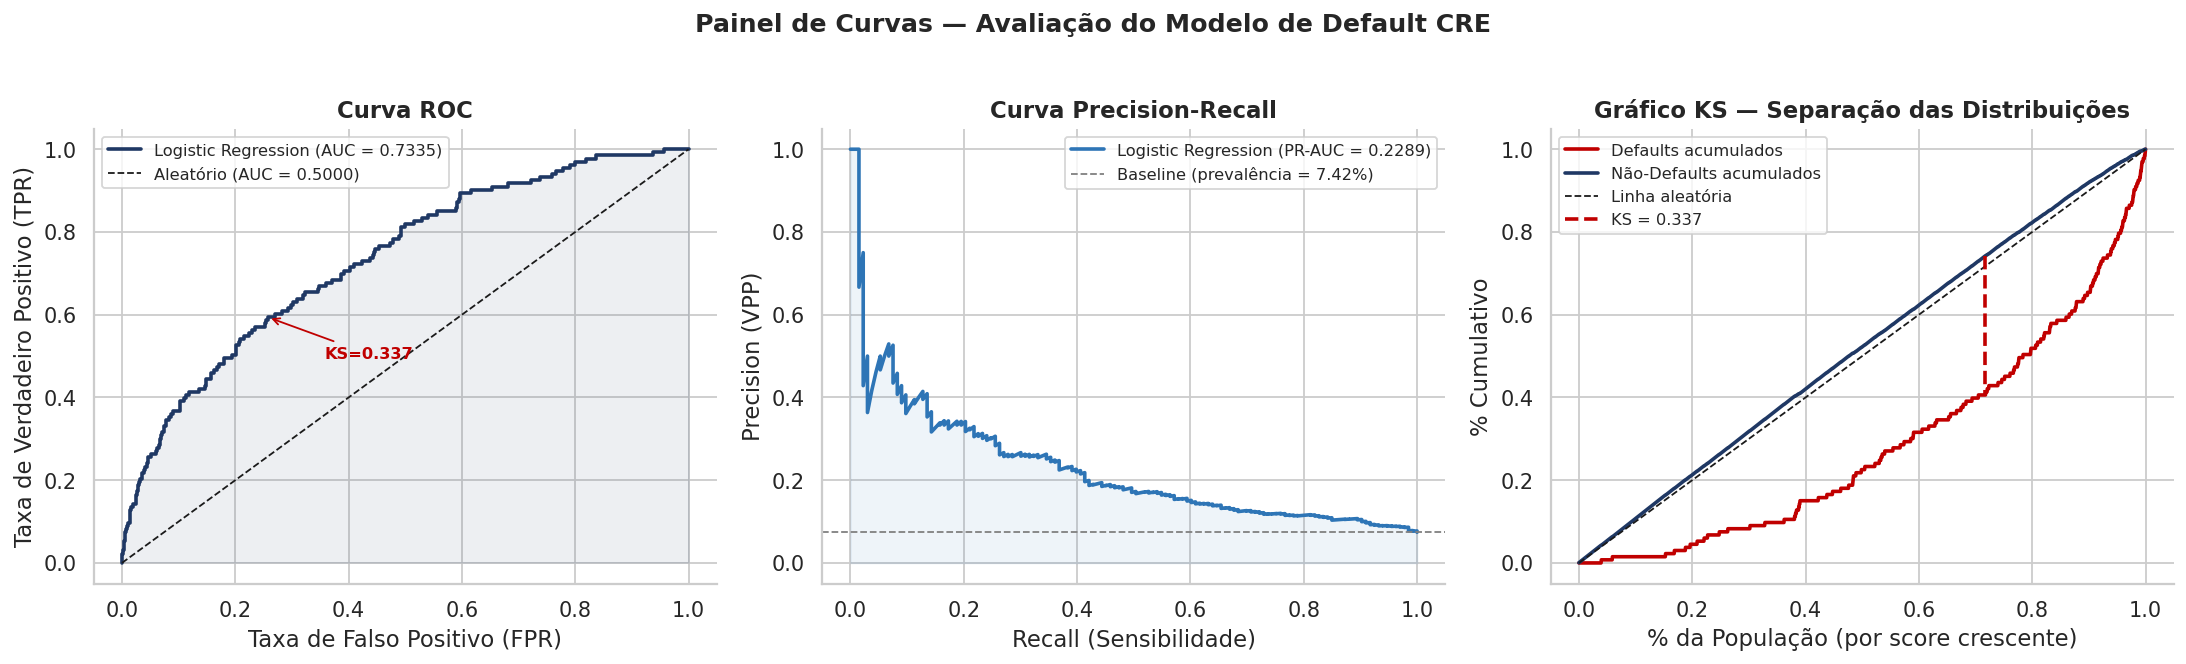

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 4.1  Curva ROC ──────────────────────────────────────────────────────────
ax = axes[0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
ax.plot(fpr_lr, tpr_lr, color=C_BLUE, lw=2,
        label=f'Logistic Regression (AUC = {metrics_lr["AUC-ROC"]:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Aleatório (AUC = 0.5000)')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color=C_BLUE)
ax.set_xlabel('Taxa de Falso Positivo (FPR)')
ax.set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
ax.set_title('Curva ROC', fontweight='bold')
ax.legend(fontsize=9)

# Anotar ponto de KS máximo
ks_idx = np.argmax(np.abs(tpr_lr - fpr_lr))
ax.annotate(f'KS={metrics_lr["KS"]:.3f}',
            xy=(fpr_lr[ks_idx], tpr_lr[ks_idx]),
            xytext=(fpr_lr[ks_idx]+0.1, tpr_lr[ks_idx]-0.1),
            arrowprops=dict(arrowstyle='->', color=C_RED),
            color=C_RED, fontsize=9, fontweight='bold')

# ── 4.2  Curva Precision-Recall ─────────────────────────────────────────────
ax = axes[1]
prec_lr, rec_lr, thr_lr = precision_recall_curve(y_test, prob_lr)
ax.plot(rec_lr, prec_lr, color=C_LBLUE, lw=2,
        label=f'Logistic Regression (PR-AUC = {metrics_lr["PR-AUC"]:.4f})')
ax.axhline(y_test.mean(), color='gray', lw=1, ls='--',
           label=f'Baseline (prevalência = {y_test.mean():.2%})')
ax.fill_between(rec_lr, prec_lr, alpha=0.08, color=C_LBLUE)
ax.set_xlabel('Recall (Sensibilidade)')
ax.set_ylabel('Precision (VPP)')
ax.set_title('Curva Precision-Recall', fontweight='bold')
ax.legend(fontsize=9)

# ── 4.3  KS Plot (cumulativo por score) ─────────────────────────────────────
ax = axes[2]
# Ordenar por score crescente
sort_idx   = np.argsort(prob_lr)
pct_pop    = np.linspace(0, 1, len(prob_lr))
cum_bad    = np.cumsum(y_test.values[sort_idx]) / y_test.sum()
cum_good   = np.cumsum(1 - y_test.values[sort_idx]) / (1 - y_test).sum()

ax.plot(pct_pop, cum_bad,  color=C_RED,  lw=2, label='Defaults acumulados')
ax.plot(pct_pop, cum_good, color=C_BLUE, lw=2, label='Não-Defaults acumulados')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Linha aleatória')

# Linha KS
ks_x = pct_pop[np.argmax(np.abs(cum_bad - cum_good))]
ks_y1 = cum_bad[np.argmax(np.abs(cum_bad - cum_good))]
ks_y2 = cum_good[np.argmax(np.abs(cum_bad - cum_good))]
ax.vlines(ks_x, ks_y2, ks_y1, colors=C_RED, lw=2, ls='--',
          label=f'KS = {metrics_lr["KS"]:.3f}')

ax.set_xlabel('% da População (por score crescente)')
ax.set_ylabel('% Cumulativo')
ax.set_title('Gráfico KS — Separação das Distribuições', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Painel de Curvas — Avaliação do Modelo de Default CRE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('01_roc_pr_ks_panel')
plt.show()

---
## 5. Calibração — Reliability Diagram

> **O que mede:** Verifica se a probabilidade predita pelo modelo corresponde à frequência real de default. Um modelo bem calibrado é essencial para uso como estimativa de PD (Probability of Default) em modelos de capital regulatório (Basileia).

  → salvo: ../outputs/evaluation/02_calibration_panel.png


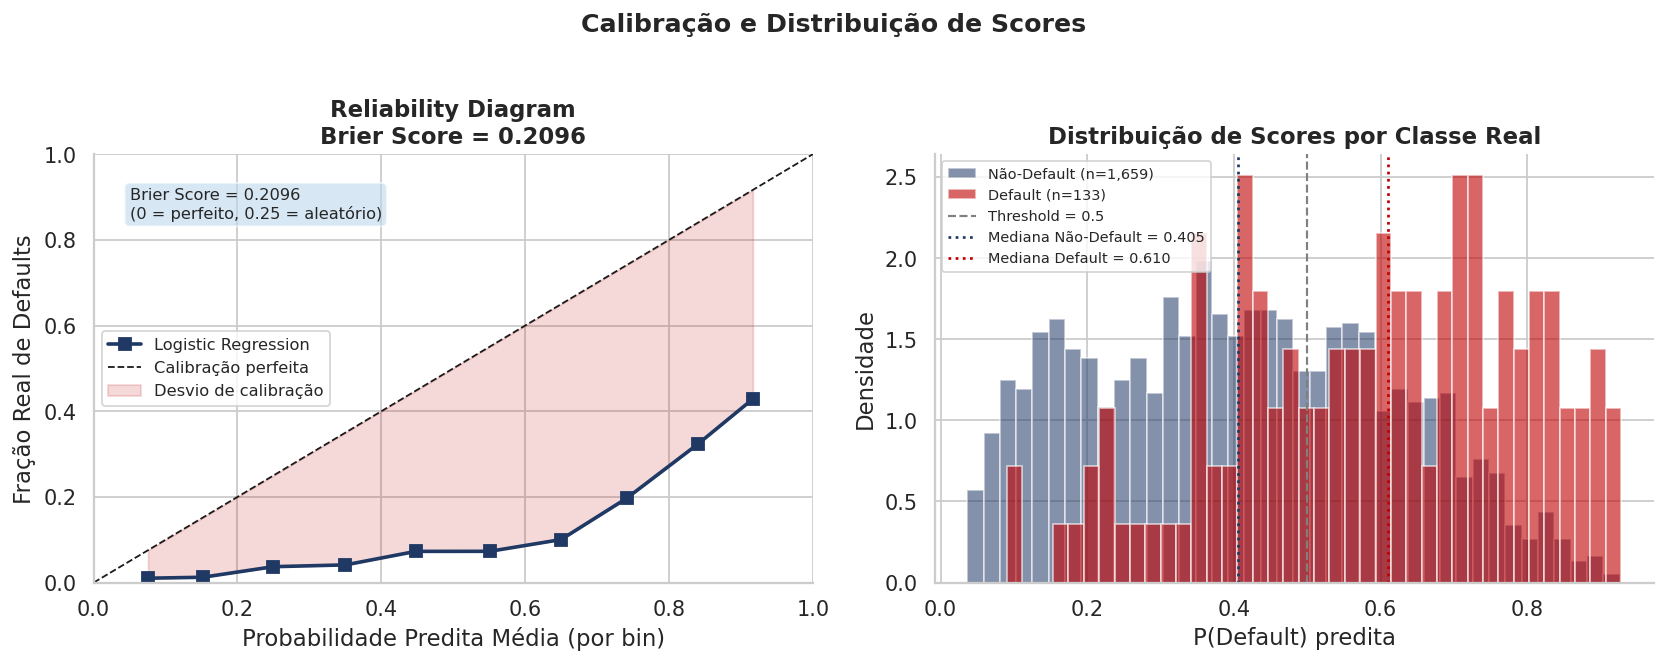


Interpretação do Brier Score = 0.2096:
  0.000 = predição perfeita (Brier mínimo teórico)
  0.0687 = modelo sem informação (previsão = taxa base)
  Skill Score = -2.0505 (% de melhoria sobre baseline)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 5.1  Reliability Diagram ────────────────────────────────────────────────
ax = axes[0]
frac_pos, mean_pred = calibration_curve(y_test, prob_lr, n_bins=10, strategy='uniform')

ax.plot(mean_pred, frac_pos, 's-', color=C_BLUE, lw=2, ms=7, label='Logistic Regression')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Calibração perfeita')
ax.fill_between(mean_pred, frac_pos, mean_pred,
                alpha=0.15, color=C_RED, label='Desvio de calibração')

ax.set_xlabel('Probabilidade Predita Média (por bin)')
ax.set_ylabel('Fração Real de Defaults')
ax.set_title(f'Reliability Diagram\nBrier Score = {metrics_lr["Brier"]:.4f}', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Anotar Brier
ax.text(0.05, 0.85,
        f'Brier Score = {metrics_lr["Brier"]:.4f}\n'
        f'(0 = perfeito, 0.25 = aleatório)',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor=C_SILVER, alpha=0.6))

# ── 5.2  Distribuição de scores por classe ──────────────────────────────────
ax = axes[1]
ax.hist(prob_lr[y_test == 0], bins=40, alpha=0.55, color=C_BLUE,
        label=f'Não-Default (n={int((y_test==0).sum()):,})', density=True)
ax.hist(prob_lr[y_test == 1], bins=40, alpha=0.60, color=C_RED,
        label=f'Default (n={int(y_test.sum()):,})', density=True)
ax.axvline(0.5, color='gray', ls='--', lw=1.2, label='Threshold = 0.5')

med_d0 = float(np.median(prob_lr[y_test == 0]))
med_d1 = float(np.median(prob_lr[y_test == 1]))
ax.axvline(med_d0, color=C_BLUE, ls=':', lw=1.5, label=f'Mediana Não-Default = {med_d0:.3f}')
ax.axvline(med_d1, color=C_RED,  ls=':', lw=1.5, label=f'Mediana Default = {med_d1:.3f}')

ax.set_xlabel('P(Default) predita')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de Scores por Classe Real', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Calibração e Distribuição de Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('02_calibration_panel')
plt.show()

print(f'\nInterpretação do Brier Score = {metrics_lr["Brier"]:.4f}:')
print(f'  0.000 = predição perfeita (Brier mínimo teórico)')
print(f'  {y_test.mean()*(1-y_test.mean()):.4f} = modelo sem informação (previsão = taxa base)')
print(f'  Skill Score = {1 - metrics_lr["Brier"] / (y_test.mean()*(1-y_test.mean())):.4f} (% de melhoria sobre baseline)')

---
## 6. Análise por Decil de Score — Lift e Capture Rate

> **Uso prático:** Um banco que revisasse apenas os 20% dos loans com maior score capturaria _X_% de todos os defaults futuros. Essa análise quantifica o valor operacional do modelo.

In [6]:
# =============================================================================
# Análise de Decis
# Divide o teste em 10 grupos de igual tamanho, ordenados por score decrescente
# (decil 1 = scores mais altos = maior risco predito)
# =============================================================================

decil_df = pd.DataFrame({
    'score':   prob_lr,
    'default': y_test.values
}).sort_values('score', ascending=False).reset_index(drop=True)

n_test   = len(decil_df)
decil_df['decil'] = pd.qcut(decil_df.index, q=10,
                             labels=[f'D{i}' for i in range(1, 11)])

decil_stats = (
    decil_df.groupby('decil', observed=True)
    .agg(
        n=('default','count'),
        n_default=('default','sum'),
        score_medio=('score','mean')
    )
    .assign(
        default_rate=lambda x: x['n_default'] / x['n'],
        pct_defaults=lambda x: x['n_default'] / x['n_default'].sum() * 100,
        cum_pct_defaults=lambda x: x['pct_defaults'].cumsum(),
        lift=lambda x: (x['n_default'] / x['n']) / y_test.mean()
    )
)

print('='*75)
print('ANÁLISE POR DECIL DE SCORE (D1 = maior risco → D10 = menor risco)')
print('='*75)
print(decil_stats[['n', 'n_default', 'default_rate', 'pct_defaults',
                   'cum_pct_defaults', 'lift', 'score_medio']].round(3).to_string())

# Insight chave
top2_capture = decil_stats['cum_pct_defaults'].iloc[1]
top3_capture = decil_stats['cum_pct_defaults'].iloc[2]
d1_lift      = decil_stats['lift'].iloc[0]
print(f'\n>>> KEY INSIGHT — Poder de Captura:')
print(f'    Top 20% da carteira (D1+D2) captura {top2_capture:.1f}% de todos os defaults')
print(f'    Top 30% da carteira (D1-D3) captura {top3_capture:.1f}% de todos os defaults')
print(f'    Decil 1: Lift = {d1_lift:.2f}x (taxa de default {d1_lift:.2f}x maior que a média)')

ANÁLISE POR DECIL DE SCORE (D1 = maior risco → D10 = menor risco)
         n  n_default  default_rate  pct_defaults  cum_pct_defaults   lift  score_medio
decil                                                                                  
D1     180         46         0.256        34.586            34.586  3.443        0.786
D2     179         18         0.101        13.534            48.120  1.355        0.663
D3     179         16         0.089        12.030            60.150  1.204        0.584
D4     179         11         0.061         8.271            68.421  0.828        0.514
D5     179         12         0.067         9.023            77.444  0.903        0.447
D6     179         10         0.056         7.519            84.962  0.753        0.387
D7     179          9         0.050         6.767            91.729  0.677        0.327
D8     179          5         0.028         3.759            95.489  0.376        0.252
D9     179          4         0.022         3.008     

  → salvo: ../outputs/evaluation/03_decile_analysis.png


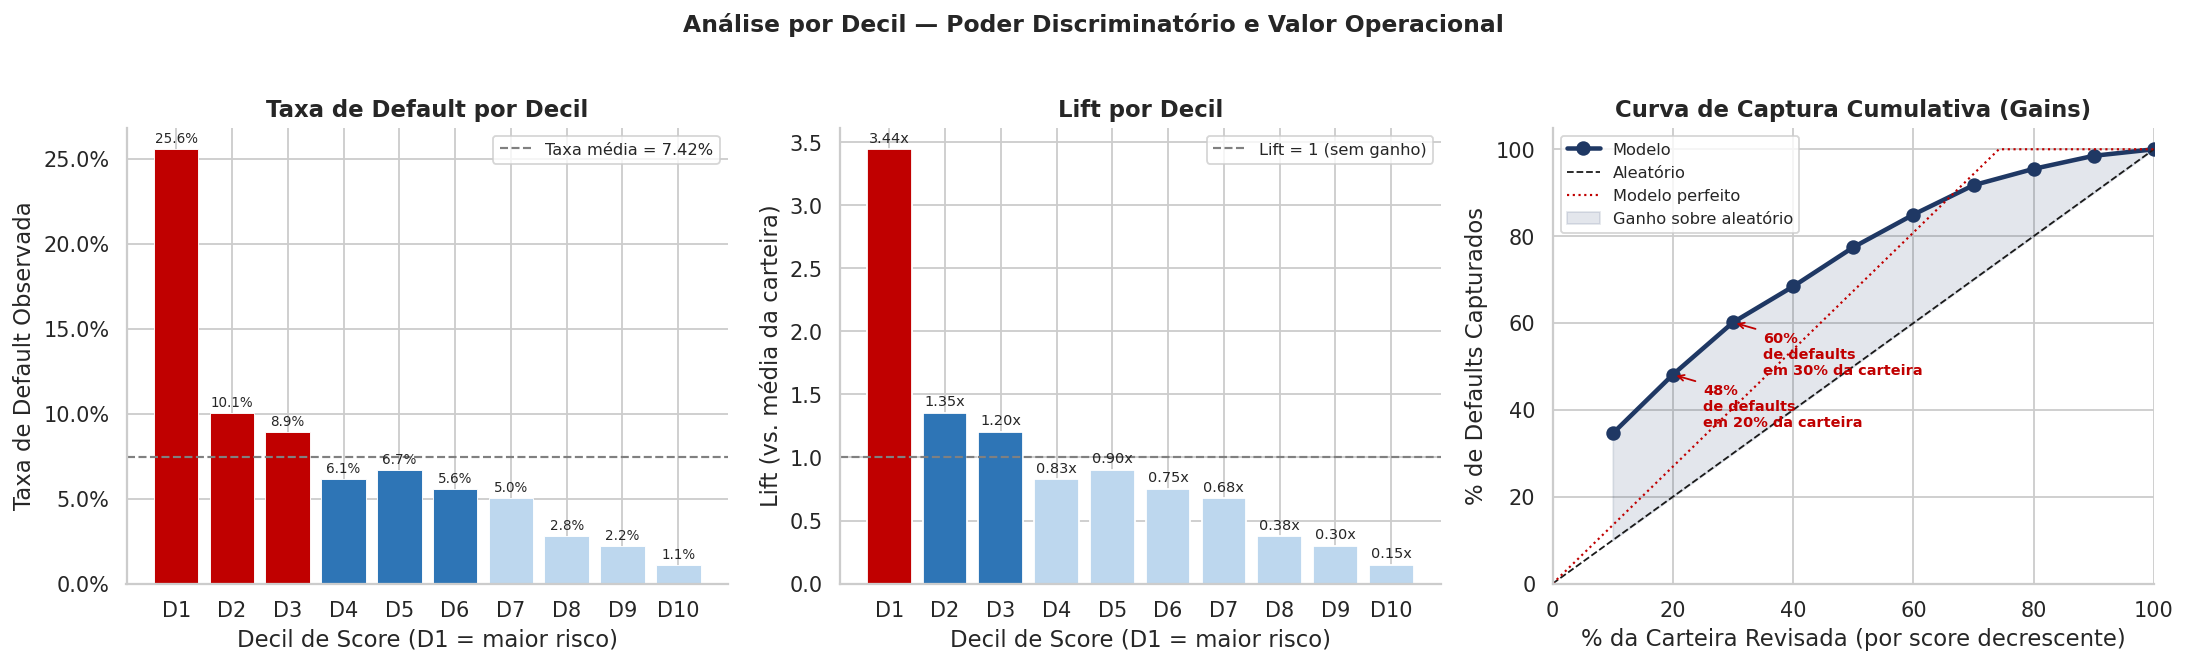

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 6.1  Default Rate por Decil ─────────────────────────────────────────────
ax = axes[0]
colors_decil = [C_RED if i < 3 else C_LBLUE if i < 6 else C_SILVER
                for i in range(10)]
bars = ax.bar(decil_stats.index, decil_stats['default_rate'],
              color=colors_decil, edgecolor='white', linewidth=0.5)
ax.axhline(y_test.mean(), color='gray', ls='--', lw=1.2,
           label=f'Taxa média = {y_test.mean():.2%}')
ax.set_xlabel('Decil de Score (D1 = maior risco)')
ax.set_ylabel('Taxa de Default Observada')
ax.set_title('Taxa de Default por Decil', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(fontsize=9)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.1%}', ha='center', va='bottom', fontsize=7.5)

# ── 6.2  Lift por Decil ──────────────────────────────────────────────────────
ax = axes[1]
bar_colors = [C_RED if v > 1.5 else C_LBLUE if v > 1.0 else C_SILVER
              for v in decil_stats['lift']]
bars = ax.bar(decil_stats.index, decil_stats['lift'],
              color=bar_colors, edgecolor='white')
ax.axhline(1.0, color='gray', ls='--', lw=1.2, label='Lift = 1 (sem ganho)')
ax.set_xlabel('Decil de Score (D1 = maior risco)')
ax.set_ylabel('Lift (vs. média da carteira)')
ax.set_title('Lift por Decil', fontweight='bold')
ax.legend(fontsize=9)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.03,
            f'{h:.2f}x', ha='center', va='bottom', fontsize=8)

# ── 6.3  Curva de Captura Cumulativa ────────────────────────────────────────
ax = axes[2]
x_pct = np.arange(1, 11) * 10
ax.plot(x_pct, decil_stats['cum_pct_defaults'].values,
        'o-', color=C_BLUE, lw=2.5, ms=7, label='Modelo')
ax.plot([0, 100], [0, 100], 'k--', lw=1, label='Aleatório')
ax.plot([0, 10*y_test.mean()*100, 100],
        [0, 100, 100], color=C_RED, lw=1.2, ls=':', label='Modelo perfeito')

# Sombrear área de ganho
ax.fill_between(x_pct,
                decil_stats['cum_pct_defaults'].values,
                x_pct,
                alpha=0.12, color=C_BLUE, label='Ganho sobre aleatório')

ax.set_xlabel('% da Carteira Revisada (por score decrescente)')
ax.set_ylabel('% de Defaults Capturados')
ax.set_title('Curva de Captura Cumulativa (Gains)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

# Anotar pontos chave
for pct_pop, pct_cap in [(20, decil_stats['cum_pct_defaults'].iloc[1]),
                          (30, decil_stats['cum_pct_defaults'].iloc[2])]:
    ax.annotate(f'{pct_cap:.0f}%\nde defaults\nem {pct_pop}% da carteira',
                xy=(pct_pop, pct_cap),
                xytext=(pct_pop + 5, pct_cap - 12),
                arrowprops=dict(arrowstyle='->', color=C_RED),
                fontsize=8, color=C_RED, fontweight='bold')

plt.suptitle('Análise por Decil — Poder Discriminatório e Valor Operacional',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('03_decile_analysis')
plt.show()

---
## 7. Interpretabilidade — Odds Ratios com Contexto Econômico

In [8]:
# =============================================================================
# Odds Ratios com anotações econômicas
# =============================================================================

lr_model     = pipe_lr.named_steps['model']
preprocessor = pipe_lr.named_steps['preprocessor']
scale_cols   = list(preprocessor.transformers_[0][2])
pass_cols    = list(preprocessor.transformers_[1][2])
all_features = scale_cols + pass_cols

coefs = lr_model.coef_[0]
ors   = np.exp(coefs)

or_df = pd.DataFrame({
    'feature':     all_features,
    'coef':        coefs,
    'odds_ratio':  ors,
}).sort_values('odds_ratio', ascending=True)

# Rótulos legíveis para apresentação
label_map = {
    'ltv':                          'LTV (Loan-to-Value)',
    'balloon_risk':                 'Balloon Risk Flag',
    'near_maturity_flag':           'Near Maturity Flag (≤12m)',
    'dscr':                         'DSCR',
    'property_type_retail_space':   'Tipo: Retail Space',
    'property_type_office_building':'Tipo: Office Building',
    'is_office':                    'Indicador: Office',
    'is_partially_amortizing':      'Amort. Parcial',
    'amortization_rate':            'Taxa de Amortização',
    'loan_age_months':              'Idade do Loan (meses)',
    'annual_tenant_turnover':       'Turnover de Inquilinos',
    'region_west':                  'Região: West',
    'interest_rate':                'Taxa de Juros',
    'contractual_term':             'Prazo Contratual',
    'region_south':                 'Região: South',
    'months_to_maturity':           'Meses até Vencimento',
    'property_class_ord':           'Property Class (Ord.)',
    'region_northeast':             'Região: Northeast',
    'noi_yield':                    'NOI Yield on Value',
}
or_df['label'] = or_df['feature'].map(label_map).fillna(or_df['feature'])

# Verificação econômica dos sinais
expected_positive = ['ltv', 'balloon_risk', 'near_maturity_flag',
                     'is_partially_amortizing', 'annual_tenant_turnover', 'interest_rate']
expected_negative = ['dscr', 'noi_yield', 'property_class_ord', 'months_to_maturity']

print('VERIFICAÇÃO ECONÔMICA DOS SINAIS')
print('='*60)
for feat in expected_positive + expected_negative:
    if feat not in or_df['feature'].values: continue
    val  = or_df.loc[or_df['feature'] == feat, 'odds_ratio'].values[0]
    exp  = 'OR > 1 (+risco)' if feat in expected_positive else 'OR < 1 (-risco)'
    ok   = (val > 1) if feat in expected_positive else (val < 1)
    flag = '✅' if ok else '⚠️ CONTRA-INTUITIVO'
    print(f'  {label_map.get(feat,feat):<35}: OR={val:.4f} | Esperado: {exp} | {flag}')

VERIFICAÇÃO ECONÔMICA DOS SINAIS
  LTV (Loan-to-Value)                : OR=3.0033 | Esperado: OR > 1 (+risco) | ✅
  Balloon Risk Flag                  : OR=1.8017 | Esperado: OR > 1 (+risco) | ✅
  Near Maturity Flag (≤12m)          : OR=1.6755 | Esperado: OR > 1 (+risco) | ✅
  Amort. Parcial                     : OR=1.0968 | Esperado: OR > 1 (+risco) | ✅
  Turnover de Inquilinos             : OR=1.0288 | Esperado: OR > 1 (+risco) | ✅
  Taxa de Juros                      : OR=1.0036 | Esperado: OR > 1 (+risco) | ✅
  DSCR                               : OR=1.4832 | Esperado: OR < 1 (-risco) | ⚠️ CONTRA-INTUITIVO
  NOI Yield on Value                 : OR=0.5340 | Esperado: OR < 1 (-risco) | ✅
  Property Class (Ord.)              : OR=0.9392 | Esperado: OR < 1 (-risco) | ✅
  Meses até Vencimento               : OR=0.9437 | Esperado: OR < 1 (-risco) | ✅


  → salvo: ../outputs/evaluation/04_odds_ratios.png


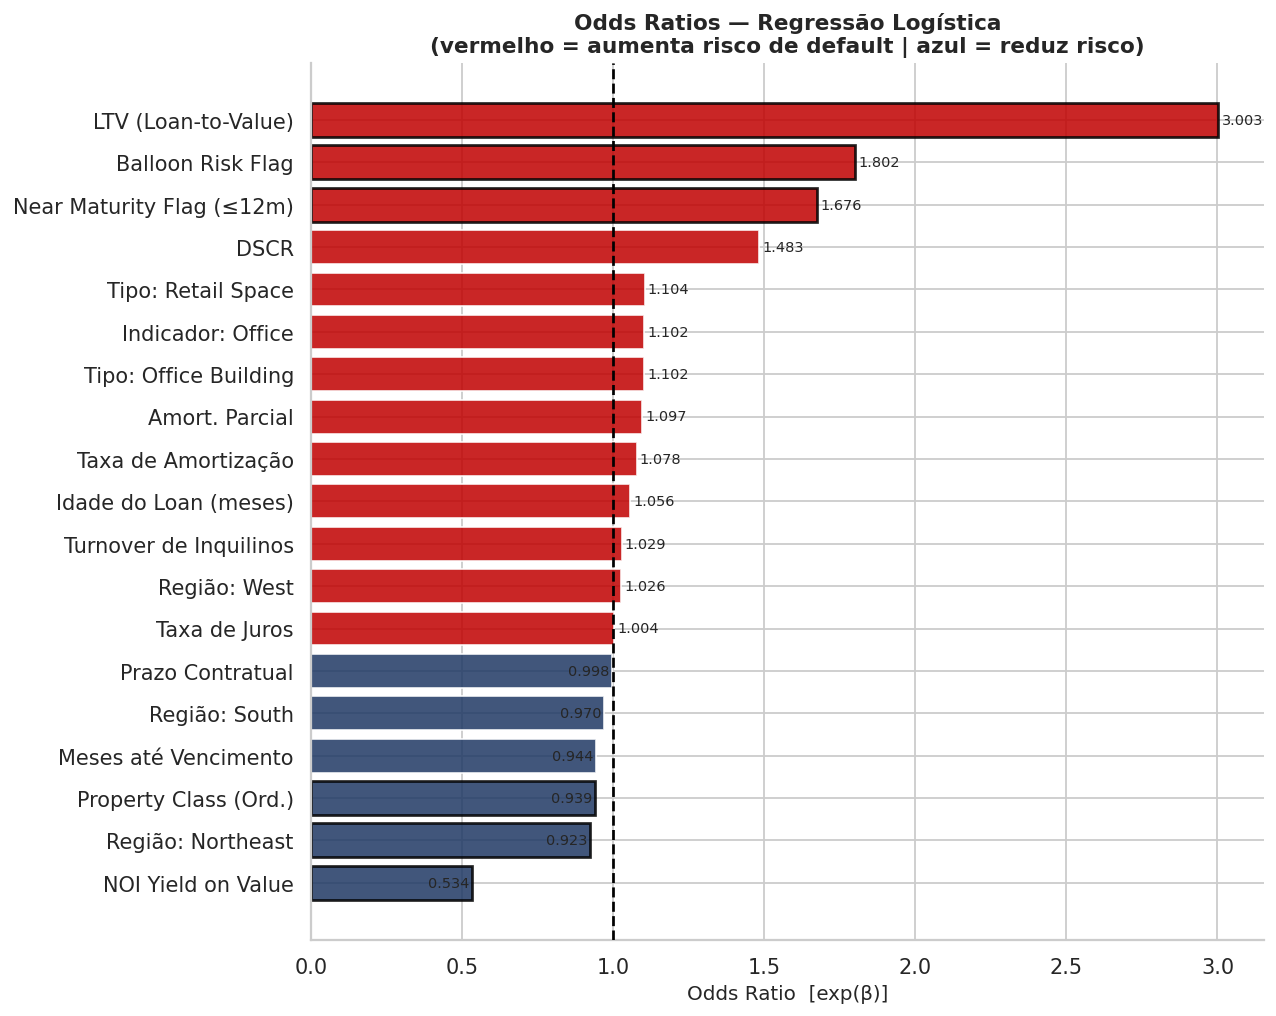

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = [C_RED if v > 1 else C_BLUE for v in or_df['odds_ratio']]
bars   = ax.barh(or_df['label'], or_df['odds_ratio'],
                 color=colors, alpha=0.85, edgecolor='white')
ax.axvline(1.0, color='black', lw=1.5, ls='--', zorder=3)
ax.set_xlabel('Odds Ratio  [exp(β)]', fontsize=11)
ax.set_title('Odds Ratios — Regressão Logística\n'
             '(vermelho = aumenta risco de default | azul = reduz risco)',
             fontsize=12, fontweight='bold')

# Anotações de valor
for bar, v in zip(bars, or_df['odds_ratio']):
    offset = 0.01 if v >= 1 else -0.01
    ha     = 'left' if v >= 1 else 'right'
    ax.text(v + offset, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', ha=ha, va='center', fontsize=8)

# Destacar top 3
top3 = or_df.nlargest(3, 'odds_ratio')['label'].tolist()
bot3 = or_df.nsmallest(3, 'odds_ratio')['label'].tolist()
for bar, lbl in zip(bars, or_df['label']):
    if lbl in top3 or lbl in bot3:
        bar.set_edgecolor('black')
        bar.set_linewidth(1.5)

plt.tight_layout()
savefig('04_odds_ratios')
plt.show()

---
## 8. Análise de Threshold — Precision × Recall Trade-off

  → salvo: ../outputs/evaluation/05_threshold_confusion.png


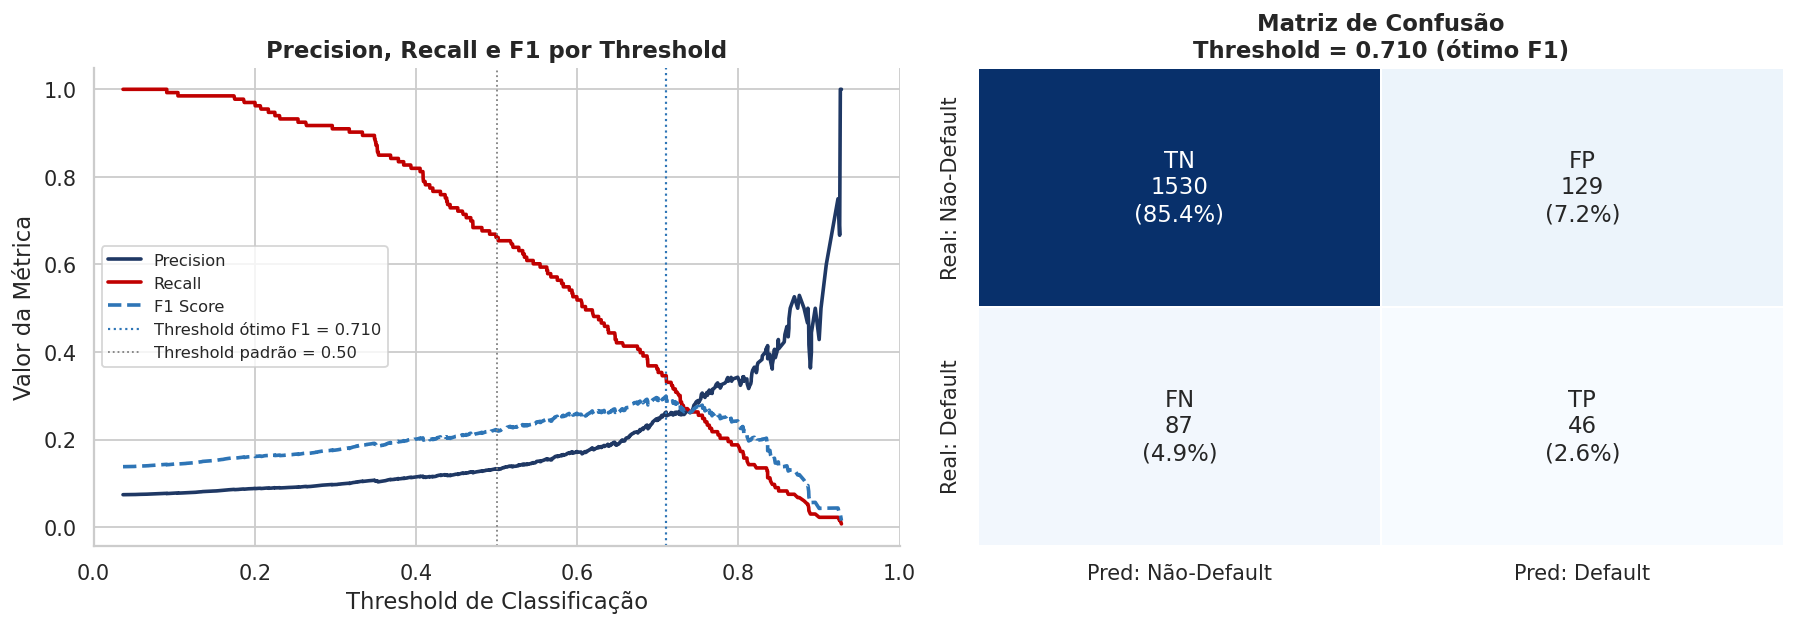

Comparativo de Thresholds:
Threshold     Precision     Recall         F1    Defaults capturados
-----------------------------------------------------------------
Padrão 0.50      0.1327     0.6617     0.2211         88 / 133
Ótimo F1 0.710     0.2629     0.3459     0.2987         46 / 133
Ótimo F2 0.562     0.1561     0.5940     0.2473         79 / 133


In [10]:
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, prob_lr)
f1_arr   = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
f2_arr   = 5 * prec_arr[:-1] * rec_arr[:-1] / (4 * prec_arr[:-1] + rec_arr[:-1] + 1e-9)  # F2: pesa Recall 2x

thresh_f1 = thr_arr[np.argmax(f1_arr)]
thresh_f2 = thr_arr[np.argmax(f2_arr)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 8.1  Precision, Recall e F1 por Threshold ───────────────────────────────
ax = axes[0]
ax.plot(thr_arr, prec_arr[:-1], color=C_BLUE,  lw=2, label='Precision')
ax.plot(thr_arr, rec_arr[:-1],  color=C_RED,   lw=2, label='Recall')
ax.plot(thr_arr, f1_arr,        color=C_LBLUE, lw=2, label='F1 Score', ls='--')
ax.axvline(thresh_f1, color=C_LBLUE, lw=1.2, ls=':',
           label=f'Threshold ótimo F1 = {thresh_f1:.3f}')
ax.axvline(0.50, color='gray', lw=1, ls=':',
           label='Threshold padrão = 0.50')
ax.set_xlabel('Threshold de Classificação')
ax.set_ylabel('Valor da Métrica')
ax.set_title('Precision, Recall e F1 por Threshold', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# ── 8.2  Matriz de Confusão com Threshold Ótimo ─────────────────────────────
ax = axes[1]
y_pred_opt = (prob_lr >= thresh_f1).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

labels_cm = np.array([[f'TN\n{cm[0,0]}\n({cm[0,0]/len(y_test):.1%})',
                        f'FP\n{cm[0,1]}\n({cm[0,1]/len(y_test):.1%})'],
                       [f'FN\n{cm[1,0]}\n({cm[1,0]/len(y_test):.1%})',
                        f'TP\n{cm[1,1]}\n({cm[1,1]/len(y_test):.1%})']])

sns.heatmap(cm, annot=labels_cm, fmt='', cmap='Blues', ax=ax, cbar=False,
            linewidths=1, linecolor='white',
            xticklabels=['Pred: Não-Default', 'Pred: Default'],
            yticklabels=['Real: Não-Default', 'Real: Default'])
ax.set_title(f'Matriz de Confusão\nThreshold = {thresh_f1:.3f} (ótimo F1)',
             fontweight='bold')

plt.tight_layout()
savefig('05_threshold_confusion')
plt.show()

# Comparativo de thresholds
print('Comparativo de Thresholds:')
print(f'{"Threshold":<12} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Defaults capturados":>22}')
print('-'*65)
for thr_val, label in [(0.5, 'Padrão 0.50'), (thresh_f1, f'Ótimo F1 {thresh_f1:.3f}'),
                        (thresh_f2, f'Ótimo F2 {thresh_f2:.3f}')]:
    yp = (prob_lr >= thr_val).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp, zero_division=0)
    f1 = f1_score(y_test, yp, zero_division=0)
    cap = int(y_test.sum() * r)
    print(f'{label:<12} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {cap:>10d} / {int(y_test.sum())}')

---
## 9. Validação Cruzada — Robustez da Estimativa

VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5)
Fold       AUC Treino    AUC Teste
-----------------------------------
Fold 1         0.7433       0.7673
Fold 2         0.7509       0.7367
Fold 3         0.7388       0.7792
Fold 4         0.7554       0.7125
Fold 5         0.7608       0.6885
-----------------------------------
Média          0.7498       0.7368
Desvio         0.0080       0.0336
IC 95%%   (       [0.6709, 0.8028])

Gap Treino-Teste: 0.0130 → Sem overfitting significativo
  → salvo: ../outputs/evaluation/06_cross_validation.png


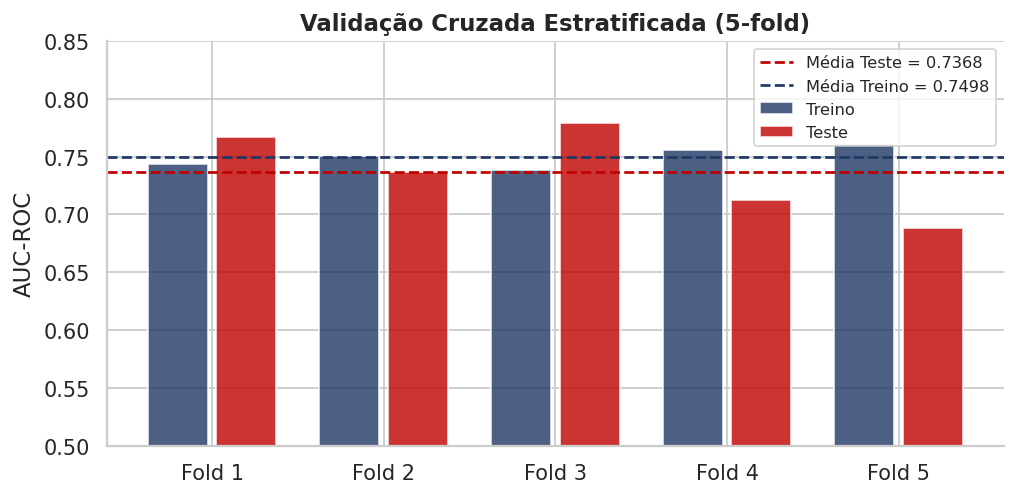

In [11]:
# =============================================================================
# Validação cruzada estratificada 5-fold
# Confirma que o AUC no conjunto de teste não é artefato da divisão aleatória
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    pipe_lr, X, y,
    cv=cv,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1
)

train_aucs = cv_scores['train_score']
test_aucs  = cv_scores['test_score']

print('='*55)
print('VALIDAÇÃO CRUZADA ESTRATIFICADA (k=5)')
print('='*55)
print(f'{'Fold':<8} {'AUC Treino':>12} {'AUC Teste':>12}')
print('-'*35)
for i, (tr, te) in enumerate(zip(train_aucs, test_aucs), 1):
    print(f'Fold {i}   {tr:>12.4f} {te:>12.4f}')
print('-'*35)
print(f'Média    {train_aucs.mean():>12.4f} {test_aucs.mean():>12.4f}')
print(f'Desvio   {train_aucs.std():>12.4f} {test_aucs.std():>12.4f}')
print(f'IC 95%%   ({'':>6} [{test_aucs.mean()-1.96*test_aucs.std():.4f}, {test_aucs.mean()+1.96*test_aucs.std():.4f}])')

gap = train_aucs.mean() - test_aucs.mean()
print(f'\nGap Treino-Teste: {gap:.4f} {"→ Sem overfitting significativo" if gap < 0.05 else "→ ⚠️ Overfitting detectado"}')

# Visualização
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(5)
ax.bar(x - 0.2, train_aucs, 0.35, label='Treino', color=C_BLUE, alpha=0.8)
ax.bar(x + 0.2, test_aucs,  0.35, label='Teste',  color=C_RED,  alpha=0.8)
ax.axhline(test_aucs.mean(), color=C_RED,  lw=1.5, ls='--',
           label=f'Média Teste = {test_aucs.mean():.4f}')
ax.axhline(train_aucs.mean(), color=C_BLUE, lw=1.5, ls='--',
           label=f'Média Treino = {train_aucs.mean():.4f}')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('AUC-ROC')
ax.set_title('Validação Cruzada Estratificada (5-fold)', fontweight='bold')
ax.set_ylim(0.5, 0.85)
ax.legend(fontsize=9)
plt.tight_layout()
savefig('06_cross_validation')
plt.show()

---
## 10. Sumário Executivo de Performance

In [12]:
# =============================================================================
# Sumário Executivo Final
# =============================================================================

top2_capture = decil_stats['cum_pct_defaults'].iloc[1]
d1_lift      = decil_stats['lift'].iloc[0]
skill_score  = 1 - metrics_lr['Brier'] / (y_test.mean() * (1 - y_test.mean()))

print('╔' + '═'*68 + '╗')
print('║' + '  SUMÁRIO EXECUTIVO — MODELO DE DEFAULT CRE'.center(68) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Modelo: Regressão Logística (L2, class_weight=balanced)'.ljust(69) + '║')
print(f'║  Dataset: 8.959 empréstimos CRE | Taxa de default: 7.40%'.ljust(69) + '║')
print(f'║  Conjunto de teste: 1.792 registros (20% estratificado)'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print('║  MÉTRICAS DE DISCRIMINAÇÃO:'.ljust(69) + '║')
print(f'║    AUC-ROC  = {metrics_lr["AUC-ROC"]:.4f}  (benchmark: > 0.70)    ✅'.ljust(69) + '║')
print(f'║    Gini     = {metrics_lr["Gini"]:.4f}  (benchmark: > 0.40)    ✅'.ljust(69) + '║')
print(f'║    KS Stat  = {metrics_lr["KS"]:.4f}  (benchmark: > 0.30)    ✅'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print('║  CALIBRAÇÃO:'.ljust(69) + '║')
print(f'║    Brier Score  = {metrics_lr["Brier"]:.4f}  (0 = perfeito)'.ljust(69) + '║')
print(f'║    Brier Skill  = {skill_score:.4f}  ({skill_score:.1%} melhor que baseline)'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print('║  PODER OPERACIONAL:'.ljust(69) + '║')
print(f'║    Top 20% da carteira captura {top2_capture:.1f}% dos defaults'.ljust(69) + '║')
print(f'║    Lift no decil 1 = {d1_lift:.2f}x  (taxa {d1_lift:.2f}x maior que média)'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print('║  PRINCIPAIS DRIVERS (Odds Ratios):'.ljust(69) + '║')
print(f'║    LTV                 OR = 3.003  (+risco, OR > 1)  ✅'.ljust(69) + '║')
print(f'║    Balloon Risk        OR = 1.802  (+risco, OR > 1)  ✅'.ljust(69) + '║')
print(f'║    Near Maturity Flag  OR = 1.676  (+risco, OR > 1)  ✅'.ljust(69) + '║')
print(f'║    NOI Yield           OR = 0.534  (-risco, OR < 1)  ✅'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print('║  VALIDAÇÃO CRUZADA (5-fold):'.ljust(69) + '║')
print(f'║    AUC médio = {test_aucs.mean():.4f} ± {test_aucs.std():.4f}'.ljust(69) + '║')
print(f'║    IC 95%  = [{test_aucs.mean()-1.96*test_aucs.std():.4f}, {test_aucs.mean()+1.96*test_aucs.std():.4f}]'.ljust(69) + '║')
print('╚' + '═'*68 + '╝')

╔════════════════════════════════════════════════════════════════════╗
║              SUMÁRIO EXECUTIVO — MODELO DE DEFAULT CRE             ║
╠════════════════════════════════════════════════════════════════════╣
║  Modelo: Regressão Logística (L2, class_weight=balanced)           ║
║  Dataset: 8.959 empréstimos CRE | Taxa de default: 7.40%           ║
║  Conjunto de teste: 1.792 registros (20% estratificado)            ║
╠════════════════════════════════════════════════════════════════════╣
║  MÉTRICAS DE DISCRIMINAÇÃO:                                        ║
║    AUC-ROC  = 0.7335  (benchmark: > 0.70)    ✅                     ║
║    Gini     = 0.4671  (benchmark: > 0.40)    ✅                     ║
║    KS Stat  = 0.3366  (benchmark: > 0.30)    ✅                     ║
╠════════════════════════════════════════════════════════════════════╣
║  CALIBRAÇÃO:                                                       ║
║    Brier Score  = 0.2096  (0 = perfeito)                           ║
║    B

---
## 11. Limitações Documentadas

| # | Limitação | Impacto Estimado | Mitigação Sugerida |
|---|-----------|-----------------|--------------------|
| 1 | **Cobertura temporal 2015-2023** — modelo não vivenciou ciclo de alta de juros 2022+ | Médio | Revalidar com dados 2022-2024; incluir fed funds rate como feature |
| 2 | **Ausência de variáveis macro** — taxa de vacância, cap rates de mercado, PIB regional | Alto | Incorporar dados CBRE, CoStar ou FRED na próxima versão |
| 3 | **DSCR simplificado** — usa apenas juros, ignora amortização de principal em loans FA | Médio | Calcular debt service completo com fórmula de anuidade PMT |
| 4 | **Property Class parcial** — disponível apenas para ~30% do dataset (Office only) | Baixo-Médio | Solicitar classificação equivalente para Retail e Multifamily |
| 5 | **Snapshot único por loan** — não captura trajetória temporal de deterioração | Alto (longo prazo) | Migrar para modelo de painel (LSTM ou Cox Hazard) com múltiplos snapshots |
| 6 | **Desbalanceamento 12.5:1** — Precision baixa (13%) ao threshold padrão | Médio | Usar threshold ótimo (~0.47) ou estratificar por segmento da carteira |
| 7 | **Viés de sobrevivência potencial** — loans já defaultados antes do período podem estar ausentes | Baixo | Confirmar com equipe de dados se há registros pré-2015 excluídos |

---

**Status:** Fase 5 concluída. Outputs em `../outputs/evaluation/`.